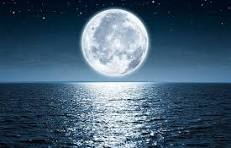

In [5]:
from PIL import Image
image = Image.open('/content/download (1).jpg')
image


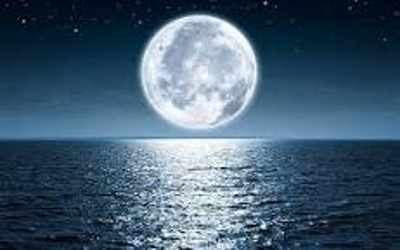

In [7]:
image_resized = image.resize((400,250))
image_resized

In [8]:
import numpy as np

In [10]:
image_array = np.array(image)/225.0 #to normalize
image_array

array([[[0.        , 0.        , 0.07555556],
        [0.03555556, 0.04      , 0.12      ],
        [0.05333333, 0.05777778, 0.13777778],
        ...,
        [0.        , 0.04444444, 0.11555556],
        [0.        , 0.04444444, 0.11555556],
        [0.        , 0.04888889, 0.12      ]],

       [[0.05333333, 0.05777778, 0.13777778],
        [0.01777778, 0.03111111, 0.10666667],
        [0.01333333, 0.01777778, 0.09777778],
        ...,
        [0.00444444, 0.05777778, 0.12888889],
        [0.00444444, 0.05777778, 0.12888889],
        [0.        , 0.04888889, 0.12      ]],

       [[0.04888889, 0.06222222, 0.13777778],
        [0.        , 0.01333333, 0.08444444],
        [0.03555556, 0.04888889, 0.12444444],
        ...,
        [0.02666667, 0.06666667, 0.14222222],
        [0.02666667, 0.06666667, 0.14222222],
        [0.00888889, 0.04888889, 0.12444444]],

       ...,

       [[0.12      , 0.13333333, 0.16444444],
        [0.08888889, 0.10222222, 0.13333333],
        [0.07111111, 0

array([[ 5, 14, 18, ..., 14, 14, 15],
       [18, 12,  9, ..., 16, 16, 15],
       [19,  7, 16, ..., 19, 19, 15],
       ...,
       [32, 25, 21, ..., 40, 40, 39],
       [32, 27, 23, ..., 44, 42, 40],
       [16, 14, 13, ..., 47, 46, 46]], dtype=uint8)
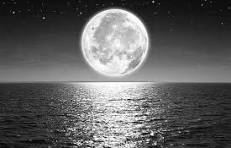

In [11]:
from cv2 import cvtColor,COLOR_BGR2GRAY
image_np=np.array(image)
grayscale_image = cvtColor(image_np,COLOR_BGR2GRAY)
grayscale_image

In [18]:
from PIL import Image,ImageEnhance, ImageOps

In [19]:
import os

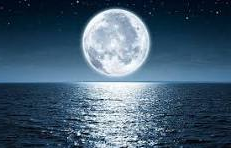

In [22]:
flipped = ImageOps.mirror(image)
flipped

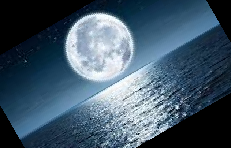

In [23]:
rotated = image.rotate(30)
rotated

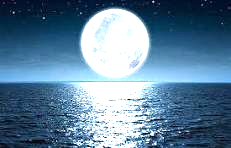

In [26]:
enhancer = ImageEnhance.Brightness(image)
brighter = enhancer.enhance(1.5)
brighter

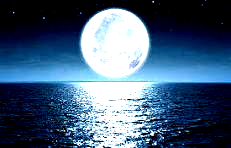

In [28]:
contrast = ImageEnhance.Contrast(image).enhance(2.0)
contrast

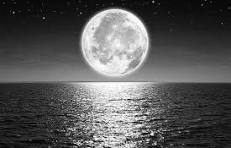

In [29]:
grayscale = ImageOps.grayscale(image)
grayscale

In [31]:
from PIL import Image, ImageEnhance, ImageOps
#PIL: Python Imaging Library (via Pillow), used for image processing.
#Image: Handles image loading, saving, and manipulation.
#ImageEnhance: Provides tools for enhancing image properties like brightness and contrast.
#ImageOps: Contains image processing utilities, such as flipping and grayscaling.
#os: A module to handle file system operations like creating directories and file paths.

import os

# Load the uploaded image
image_path = "/content/download (1).jpg"  # Replace with your image file path
image = Image.open(image_path)

# Create a directory for augmented images
augmented_dir = "augmented_images"
#Creates the directory augmented_images
os.makedirs(augmented_dir, exist_ok=True)
 #Ensures no error is raised if the directory already exists.

# Augmentation functions
def augment_image(image, output_dir):
    # 1. Horizontal Flip
    # Flips the image horizontally (mirroring).
    flipped = ImageOps.mirror(image)
    #Saves the flipped image as flipped.jpeg in the output_dir
    flipped.save(os.path.join(output_dir, "flipped.jpeg"))

    # 2. Rotate
    rotated = image.rotate(30)
    #Rotates the image by 30 degrees (counterclockwise by default)
    rotated.save(os.path.join(output_dir, "rotated.jpeg"))

    # 3. Brightness Adjustment
    enhancer = ImageEnhance.Brightness(image)
    #Adjusts brightness by a factor of 1.5 (1.0 = original brightness).
    brighter = enhancer.enhance(1.5)
    brighter.save(os.path.join(output_dir, "brighter.jpeg"))

    # 4. Contrast Adjustment
    contrast = ImageEnhance.Contrast(image).enhance(2.0)
    #Doubles the image's contrast (2.0 = twice the original contrast).

    contrast.save(os.path.join(output_dir, "contrast.jpeg"))

    # 5. Grayscale
    grayscale = ImageOps.grayscale(image)
    grayscale.save(os.path.join(output_dir, "grayscale.jpeg"))

# Apply augmentations
augment_image(image, augmented_dir)
#Calls the augment_image function to apply all augmentations on the loaded image and save the results in the augmented_images directory.

# List the augmented files
print("Augmented images saved in:", augmented_dir)
print("Generated files:", os.listdir(augmented_dir))

Augmented images saved in: augmented_images
Generated files: ['rotated.jpeg', 'brighter.jpeg', 'flipped.jpeg', 'grayscale.jpeg', 'contrast.jpeg']


In [38]:
import matplotlib.pyplot as plt

In [34]:
import os

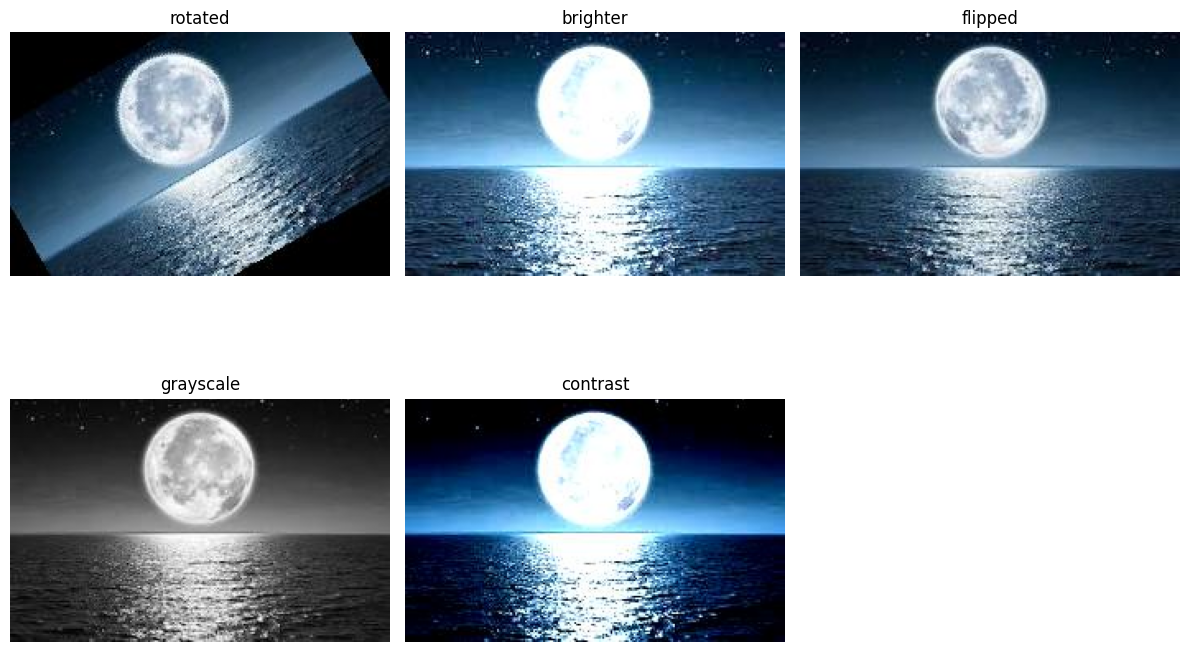

In [49]:
augmented_dir = "augmented_images"
augmented_images = os.listdir(augmented_dir)
plt.figure(figsize=(12,8))
for i, img_file in enumerate(augmented_images):
    img_path = os.path.join(augmented_dir, img_file)
    img = Image.open(img_path) # Changed to PIL.Image.open
    plt.subplot(2,3,i+1)
    plt.imshow(img,cmap="gray" if img.mode == "L" else None)
    plt.title(img_file.split('.')[0])
    plt.axis("off")
plt.tight_layout()
plt.show()